# NYC Taxi Demand — Data Framing & Feature Engineering

**CSAI-801 | Group 4**

This notebook loads the raw January 2025 NYC Yellow Taxi data, cleans it, aggregates it into hourly demand per zone, and engineers all features required for the ML modeling notebook.

Data source: [NYC TLC Trip Record Data](https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page)


## 1. Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

try:
    from statsmodels.stats.outliers_influence import variance_inflation_factor

except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "statsmodels", "-q"])
    from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


## 2. Loading the Data

We load the raw taxi parquet file and the official Taxi Zone Lookup CSV to map Location IDs → Borough names.


In [2]:
# Loading raw January 2025 taxi data
df = pd.read_parquet('yellow_tripdata_2025-01.parquet')

# Loading official Taxi Zone Lookup for Borough mapping
lookup_url = 'https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv'
zone_lookup = pd.read_csv(lookup_url)

print(f'Raw data shape  : {df.shape}')
print(f'Columns         : {df.columns.tolist()}')
df.head()


Raw data shape  : (3475226, 20)
Columns         : ['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'Airport_fee', 'cbd_congestion_fee']


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,1,2025-01-01 00:18:38,2025-01-01 00:26:59,1.0,1.60,1.0,N,229,237,1,10.0,3.5,0.5,3.00,0.0,1.0,18.00,2.5,0.0,0.0
1,1,2025-01-01 00:32:40,2025-01-01 00:35:13,1.0,0.50,1.0,N,236,237,1,5.1,3.5,0.5,2.02,0.0,1.0,12.12,2.5,0.0,0.0
2,1,2025-01-01 00:44:04,2025-01-01 00:46:01,1.0,0.60,1.0,N,141,141,1,5.1,3.5,0.5,2.00,0.0,1.0,12.10,2.5,0.0,0.0
3,2,2025-01-01 00:14:27,2025-01-01 00:20:01,3.0,0.52,1.0,N,244,244,2,7.2,1.0,0.5,0.00,0.0,1.0,9.70,0.0,0.0,0.0
4,2,2025-01-01 00:21:34,2025-01-01 00:25:06,3.0,0.66,1.0,N,244,116,2,5.8,1.0,0.5,0.00,0.0,1.0,8.30,0.0,0.0,0.0


## 3. Exploratory Overview

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3475226 entries, 0 to 3475225
Data columns (total 20 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int32         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int32         
 8   DOLocationID           int32         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  Airport_fee           

In [4]:
df.describe()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
count,3.475226e+06,3475226,3475226,2.935077e+06,3.475226e+06,2.935077e+06,3.475226e+06,3.475226e+06,3.475226e+06,3.475226e+06,3.475226e+06,3.475226e+06,3.475226e+06,3.475226e+06,3.475226e+06,3.475226e+06,2.935077e+06,2.935077e+06,3.475226e+06
mean,1.785428e+00,2025-01-17 11:02:55.910964,2025-01-17 11:17:56.997901,1.297859e+00,5.855126e+00,2.482535e+00,1.651916e+02,1.641252e+02,1.036623e+00,1.708180e+01,1.317737e+00,4.780991e-01,2.959813e+00,4.493081e-01,9.547946e-01,2.561129e+01,2.225237e+00,1.239111e-01,4.834093e-01
min,1.000000e+00,2024-12-31 20:47:55,2024-12-18 07:52:40,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,-9.000000e+02,-7.500000e+00,-5.000000e-01,-8.600000e+01,-1.269400e+02,-1.000000e+00,-9.010000e+02,-2.500000e+00,-1.750000e+00,-7.500000e-01
25%,2.000000e+00,2025-01-10 07:59:01,2025-01-10 08:15:29.500000,1.000000e+00,9.800000e-01,1.000000e+00,1.320000e+02,1.130000e+02,1.000000e+00,8.600000e+00,0.000000e+00,5.000000e-01,0.000000e+00,0.000000e+00,1.000000e+00,1.520000e+01,2.500000e+00,0.000000e+00,0.000000e+00
50%,2.000000e+00,2025-01-17 15:41:33,2025-01-17 15:59:34,1.000000e+00,1.670000e+00,1.000000e+00,1.620000e+02,1.620000e+02,1.000000e+00,1.211000e+01,0.000000e+00,5.000000e-01,2.450000e+00,0.000000e+00,1.000000e+00,1.995000e+01,2.500000e+00,0.000000e+00,7.500000e-01
75%,2.000000e+00,2025-01-24 19:34:06,2025-01-24 19:48:31,1.000000e+00,3.100000e+00,1.000000e+00,2.340000e+02,2.340000e+02,1.000000e+00,1.950000e+01,2.500000e+00,5.000000e-01,3.930000e+00,0.000000e+00,1.000000e+00,2.778000e+01,2.500000e+00,0.000000e+00,7.500000e-01
max,7.000000e+00,2025-02-01 00:00:44,2025-02-01 23:44:11,9.000000e+00,2.764236e+05,9.900000e+01,2.650000e+02,2.650000e+02,5.000000e+00,8.633721e+05,1.500000e+01,1.050000e+01,4.000000e+02,1.709400e+02,1.000000e+00,8.633804e+05,2.500000e+00,6.750000e+00,7.500000e-01
std,4.263282e-01,NaN,NaN,7.507503e-01,5.646016e+02,1.163277e+01,6.452948e+01,6.940169e+01,7.013334e-01,4.634729e+02,1.861509e+00,1.374623e-01,3.779681e+00,2.002582e+00,2.781938e-01,4.636585e+02,9.039932e-01,4.725090e-01,3.619307e-01


## 4. Cleaning & Spatio-Temporal Aggregation

**Steps:**
1. Drop rows with missing critical fields (location ID or timestamp)
2. Floor timestamps to the nearest hour → `time_window`
3. Aggregate individual trips into hourly demand counts per zone (`trip_count`)
4. **Apply 99.9th percentile global outlier cap before creating lag features** — preventing extreme spikes from poisoning historical memory signals
5. **Building a complete ( zone-hour ) grid filling missing slots with 0** to prevents time jumps in lag computation
6. Merge with zone lookup to attach Borough names and remove Unknown zones


In [5]:
# Step 1: Dropping rows missing critical values
df = df.dropna(subset=['PULocationID', 'tpep_pickup_datetime'])


In [6]:
# Step 2: Creating hourly time window
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
df['time_window'] = df['tpep_pickup_datetime'].dt.floor('h')


In [7]:
# Step 3: Aggregating into hourly demand per zone
demand_df = (df.groupby(['PULocationID', 'time_window']).size().reset_index(name='trip_count'))


In [8]:
# Step 4: Global outlier cap before lags (prevents lag poisoning)
upper_limit = demand_df['trip_count'].quantile(0.999)
demand_df['trip_count'] = np.where(demand_df['trip_count'] > upper_limit, upper_limit, demand_df['trip_count'])
print(f'Global outlier cap (99.9th pct): {upper_limit:.2f}')


Global outlier cap (99.9th pct): 590.90


In [9]:
# Step 5: Building complete ( zone × hour ) grid (filling missing slots with 0)
all_zones = demand_df['PULocationID'].unique()
all_hours = pd.date_range(start=demand_df['time_window'].min(), end=demand_df['time_window'].max(), freq='h')
multi_index = pd.MultiIndex.from_product([all_zones, all_hours], names=['PULocationID', 'time_window'])
demand_df = (demand_df.set_index(['PULocationID', 'time_window'])
             .reindex(multi_index, fill_value=0).reset_index())
print(f'Shape after complete grid fill: {demand_df.shape}')


Shape after complete grid fill: (195489, 3)


In [10]:
# Step 6: Spatial mapping — attach Borough names
demand_df = demand_df.merge(zone_lookup[['LocationID', 'Borough']],
                            left_on='PULocationID', right_on='LocationID',
                            how='left').drop('LocationID', axis=1)
demand_df = demand_df[demand_df['Borough'] != 'Unknown']
print(f'Shape after Borough filter: {demand_df.shape}')
demand_df.head()


Shape after Borough filter: (194740, 4)


,PULocationID,time_window,trip_count,Borough
0,1,2024-12-31 20:00:00,0.0,EWR
1,1,2024-12-31 21:00:00,0.0,EWR
2,1,2024-12-31 22:00:00,0.0,EWR
3,1,2024-12-31 23:00:00,0.0,EWR
4,1,2025-01-01 00:00:00,0.0,EWR


## 5. Sorting by Zone & Time

> **Critical step:** we sorted the data by `PULocationID` then `time_window` before creating any lag or rolling features.


In [11]:
demand_df = demand_df.sort_values(['PULocationID', 'time_window']).reset_index(drop=True)
print("Data sorted by ['PULocationID', 'time_window'] ✓")
print(demand_df[['PULocationID', 'time_window', 'trip_count']].head(10))


Data sorted by ['PULocationID', 'time_window'] ✓
   PULocationID         time_window  trip_count
0             1 2024-12-31 20:00:00         0.0
1             1 2024-12-31 21:00:00         0.0
2             1 2024-12-31 22:00:00         0.0
3             1 2024-12-31 23:00:00         0.0
4             1 2025-01-01 00:00:00         0.0
5             1 2025-01-01 01:00:00         0.0
6             1 2025-01-01 02:00:00         0.0
7             1 2025-01-01 03:00:00         0.0
8             1 2025-01-01 04:00:00         0.0
9             1 2025-01-01 05:00:00         0.0


## 6. Feature Engineering

### 6.1 Basic Temporal Features

| Feature | Description |
|---|---|
| `hour` / `hour_num` | Hour of day (0–23) |
| `day` | Day of month (1–31) |
| `day_of_week` | 0=Monday … 6=Sunday |
| `month` | Month number (1 for January) |
| `is_weekend` | 1 if Saturday or Sunday, 0 otherwise |
| `is_holiday` | 1 for Jan 1 (New Year's Day) and Jan 20 (MLK Day) |


In [12]:
demand_df['hour']        = demand_df['time_window'].dt.hour
demand_df['hour_num']    = demand_df['hour']
demand_df['day']         = demand_df['time_window'].dt.day
demand_df['day_of_week'] = demand_df['time_window'].dt.dayofweek
demand_df['month']       = demand_df['time_window'].dt.month
demand_df['is_weekend']  = demand_df['day_of_week'].isin([5, 6]).astype(int)
holidays = ['2025-01-01', '2025-01-20']
demand_df['is_holiday']  = demand_df['time_window'].dt.strftime('%Y-%m-%d').isin(holidays).astype(int)
print(demand_df[['time_window', 'hour', 'day', 'day_of_week', 'month', 'is_weekend', 'is_holiday']].head())


          time_window  hour  day  day_of_week  month  is_weekend  is_holiday
0 2024-12-31 20:00:00    20   31            1     12           0           0
1 2024-12-31 21:00:00    21   31            1     12           0           0
2 2024-12-31 22:00:00    22   31            1     12           0           0
3 2024-12-31 23:00:00    23   31            1     12           0           0
4 2025-01-01 00:00:00     0    1            2      1           0           1


### 6.2 Cyclical Encoding (Sin/Cos)

Raw integer hours treat 23 and 0 as far apart, but they are adjacent. Sine/Cosine encoding wraps the cycle.

| Feature | Cycle | Purpose |
|---|---|---|
| `hour_sin` / `hour_cos` | 24-hour | Daily rhythm |
| `day_sin` / `day_cos` | 7-day | Weekly rhythm |


In [13]:
demand_df['hour_sin'] = np.sin(2 * np.pi * demand_df['hour'] / 24)
demand_df['hour_cos'] = np.cos(2 * np.pi * demand_df['hour'] / 24)
demand_df['day_sin']  = np.sin(2 * np.pi * demand_df['day_of_week'] / 7)
demand_df['day_cos']  = np.cos(2 * np.pi * demand_df['day_of_week'] / 7)
print(demand_df[['hour', 'hour_sin', 'hour_cos', 'day_of_week', 'day_sin', 'day_cos']].head())


   hour  hour_sin  hour_cos  day_of_week   day_sin   day_cos
0    20 -0.866025  0.500000            1  0.781831  0.623490
1    21 -0.707107  0.707107            1  0.781831  0.623490
2    22 -0.500000  0.866025            1  0.781831  0.623490
3    23 -0.258819  0.965926            1  0.781831  0.623490
4     0  0.000000  1.000000            2  0.974928 -0.222521


### 6.3 Spatio-Temporal Lag Features

| Feature | Shift | What it captures |
|---|---|---|
| `lag_1` | 1 hour back | Very recent momentum |
| `lag_2` | 2 hours back | Short-term trend direction |
| `lag_24` | 24 hours back | Same hour yesterday |
| `lag_168` | 168 hours back | Same hour last week |


In [14]:
demand_df['lag_1']   = demand_df.groupby('PULocationID')['trip_count'].shift(1)
demand_df['lag_2']   = demand_df.groupby('PULocationID')['trip_count'].shift(2)
demand_df['lag_24']  = demand_df.groupby('PULocationID')['trip_count'].shift(24)
demand_df['lag_168'] = demand_df.groupby('PULocationID')['trip_count'].shift(168)
print(demand_df[['PULocationID', 'time_window', 'trip_count', 'lag_1', 'lag_2', 'lag_24', 'lag_168']].head(10))


   PULocationID         time_window  trip_count  lag_1  lag_2  lag_24  lag_168
0             1 2024-12-31 20:00:00         0.0    NaN    NaN     NaN      NaN
1             1 2024-12-31 21:00:00         0.0    0.0    NaN     NaN      NaN
2             1 2024-12-31 22:00:00         0.0    0.0    0.0     NaN      NaN
3             1 2024-12-31 23:00:00         0.0    0.0    0.0     NaN      NaN
4             1 2025-01-01 00:00:00         0.0    0.0    0.0     NaN      NaN
5             1 2025-01-01 01:00:00         0.0    0.0    0.0     NaN      NaN
6             1 2025-01-01 02:00:00         0.0    0.0    0.0     NaN      NaN
7             1 2025-01-01 03:00:00         0.0    0.0    0.0     NaN      NaN
8             1 2025-01-01 04:00:00         0.0    0.0    0.0     NaN      NaN
9             1 2025-01-01 05:00:00         0.0    0.0    0.0     NaN      NaN


### 6.4 Rolling Window Features (Trend & Volatility)

| Feature | Description |
|---|---|
| `rolling_mean_3` | Average demand over previous 3 hours |
| `rolling_std_3` | Std deviation over previous 3 hours |


In [15]:
demand_df['rolling_mean_3'] = (demand_df.groupby('PULocationID')['trip_count']
                               .transform(lambda x: x.shift(1).rolling(window=3).mean()))
demand_df['rolling_std_3']  = (demand_df.groupby('PULocationID')['trip_count']
                               .transform(lambda x: x.shift(1).rolling(window=3).std()))
print(demand_df[['PULocationID', 'time_window', 'trip_count', 'rolling_mean_3', 'rolling_std_3']].head(10))


   PULocationID         time_window  trip_count  rolling_mean_3  rolling_std_3
0             1 2024-12-31 20:00:00         0.0             NaN            NaN
1             1 2024-12-31 21:00:00         0.0             NaN            NaN
2             1 2024-12-31 22:00:00         0.0             NaN            NaN
3             1 2024-12-31 23:00:00         0.0             0.0            0.0
4             1 2025-01-01 00:00:00         0.0             0.0            0.0
5             1 2025-01-01 01:00:00         0.0             0.0            0.0
6             1 2025-01-01 02:00:00         0.0             0.0            0.0
7             1 2025-01-01 03:00:00         0.0             0.0            0.0
8             1 2025-01-01 04:00:00         0.0             0.0            0.0
9             1 2025-01-01 05:00:00         0.0             0.0            0.0


### 6.5 Spatial Feature — Borough One-Hot Encoding

> `drop_first=True` removes one category to avoid the dummy variable trap.


In [16]:
borough_dummies = pd.get_dummies(demand_df['Borough'], prefix='borough', drop_first=True)
demand_df = pd.concat([demand_df, borough_dummies], axis=1)
borough_cols = borough_dummies.columns.tolist()
demand_df[['Borough'] + borough_cols].head(10)


,Borough,borough_Brooklyn,borough_EWR,borough_Manhattan,borough_Queens,borough_Staten Island
0,EWR,False,True,False,False,False
1,EWR,False,True,False,False,False
2,EWR,False,True,False,False,False
3,EWR,False,True,False,False,False
4,EWR,False,True,False,False,False
5,EWR,False,True,False,False,False
6,EWR,False,True,False,False,False
7,EWR,False,True,False,False,False
8,EWR,False,True,False,False,False
9,EWR,False,True,False,False,False


## 7. Final Post-Processing

1. **Dropping NaN rows** introduced by lag/rolling features
2. **Final Winsorization** of target variable at 99th percentile
3. **Saving** the ML-ready dataset


In [17]:
final_df = demand_df.dropna().reset_index(drop=True)
print(f'Rows after dropping lag-induced NaNs: {final_df.shape[0]:,}')


Rows after dropping lag-induced NaNs: 150,479


In [18]:
final_cap = final_df['trip_count'].quantile(0.99)
final_df['trip_count'] = np.where(final_df['trip_count'] > final_cap, final_cap, final_df['trip_count'])
print(f"Target 'trip_count' Winsorized at: {final_cap:.2f}")


Target 'trip_count' Winsorized at: 297.22


In [19]:
final_df.to_parquet('taxi_demand_ml_ready.parquet')
print(f'Final shape: {final_df.shape}')
final_df.head()


Final shape: (150479, 26)


,PULocationID,time_window,trip_count,Borough,hour,hour_num,day,day_of_week,month,is_weekend,...,lag_2,lag_24,lag_168,rolling_mean_3,rolling_std_3,borough_Brooklyn,borough_EWR,borough_Manhattan,borough_Queens,borough_Staten Island
0,1,2025-01-07 20:00:00,0.0,EWR,20,20,7,1,1,0,...,0.0,0.0,0.0,0.666667,1.154701,False,True,False,False,False
1,1,2025-01-07 21:00:00,0.0,EWR,21,21,7,1,1,0,...,2.0,0.0,0.0,0.666667,1.154701,False,True,False,False,False
2,1,2025-01-07 22:00:00,0.0,EWR,22,22,7,1,1,0,...,0.0,0.0,0.0,0.666667,1.154701,False,True,False,False,False
3,1,2025-01-07 23:00:00,0.0,EWR,23,23,7,1,1,0,...,0.0,0.0,0.0,0.000000,0.000000,False,True,False,False,False
4,1,2025-01-08 00:00:00,0.0,EWR,0,0,8,2,1,0,...,0.0,0.0,0.0,0.000000,0.000000,False,True,False,False,False


## 8. Complete Feature Summary

In [20]:
feature_summary = {
    'Feature': ['trip_count','hour / hour_num','day','day_of_week','month',
                'is_weekend','is_holiday','hour_sin','hour_cos','day_sin','day_cos',
                'lag_1','lag_2','lag_24','lag_168','rolling_mean_3','rolling_std_3','borough_*'],
    'Type': ['Target','Temporal','Temporal','Temporal','Temporal','Binary Flag','Binary Flag',
             'Cyclical','Cyclical','Cyclical','Cyclical','Lag','Lag','Lag','Lag',
             'Rolling','Rolling','Spatial'],
    'Description': [
        'Hourly trip demand per zone (Winsorized at 99th pct)',
        'Hour of day (0-23)', 'Day of month (1-31)', '0=Mon...6=Sun', 'Month number',
        '1 if Saturday or Sunday', '1 for Jan 1 and Jan 20',
        'Sin encoding of hour', 'Cos encoding of hour',
        'Sin encoding of day_of_week', 'Cos encoding of day_of_week',
        'Demand 1 hour ago (same zone)', 'Demand 2 hours ago (same zone)',
        'Demand 24 hours ago — yesterday same hour',
        'Demand 168 hours ago — last week same hour',
        'Rolling avg of previous 3 hours (same zone)',
        'Rolling std of previous 3 hours — volatility signal',
        'One-hot encoded Borough dummies (drop_first=True)'
    ]
}
summary_df = pd.DataFrame(feature_summary)
print(summary_df.to_string(index=False))
print(f'\nTotal columns in final_df : {final_df.shape[1]}')
print(f'Total rows                : {final_df.shape[0]:,}')


        Feature        Type                                          Description
     trip_count      Target Hourly trip demand per zone (Winsorized at 99th pct)
hour / hour_num    Temporal                                   Hour of day (0-23)
            day    Temporal                                  Day of month (1-31)
    day_of_week    Temporal                                        0=Mon...6=Sun
          month    Temporal                                         Month number
     is_weekend Binary Flag                              1 if Saturday or Sunday
     is_holiday Binary Flag                               1 for Jan 1 and Jan 20
       hour_sin    Cyclical                                 Sin encoding of hour
       hour_cos    Cyclical                                 Cos encoding of hour
        day_sin    Cyclical                          Sin encoding of day_of_week
        day_cos    Cyclical                          Cos encoding of day_of_week
          lag_1         Lag 

## 9. Feature Correlation Heatmap

Shows predictive strength of all engineered features against `trip_count`.


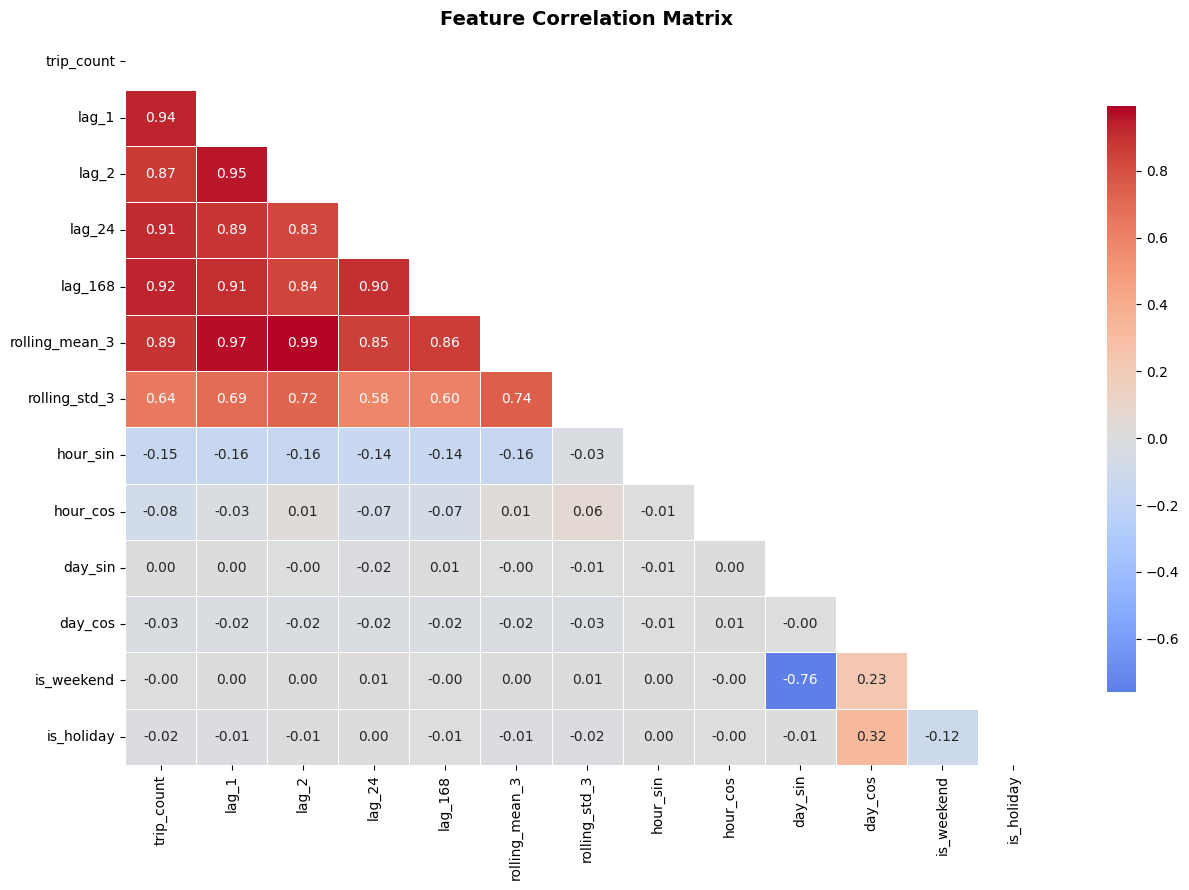


Correlations with trip_count (ranked):
lag_1             0.935135
lag_168           0.924725
lag_24            0.912298
rolling_mean_3    0.889799
lag_2             0.870689
rolling_std_3     0.639177
day_sin           0.001000
is_weekend       -0.001241
is_holiday       -0.015431
day_cos          -0.026585
hour_cos         -0.076557
hour_sin         -0.147140


In [21]:
corr_cols = ['trip_count','lag_1','lag_2','lag_24','lag_168',
             'rolling_mean_3','rolling_std_3','hour_sin','hour_cos',
             'day_sin','day_cos','is_weekend','is_holiday']

corr = final_df[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(13, 9))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

print('\nCorrelations with trip_count (ranked):')
print(corr['trip_count'].drop('trip_count').sort_values(ascending=False).to_string())


## 10. Multicollinearity Check — VIF Analysis
*(Added per TA recommendation — Lectures 11 & 12)*

Many of our lag and rolling features are highly correlated (lag_1, lag_2, rolling_mean_3 all track recent demand).
**Multicollinearity** does not hurt tree-based models but destabilises linear models by inflating coefficient variance.

**Variance Inflation Factor (VIF):** measures how much each feature's variance is inflated by correlations with others.
- VIF < 5 → acceptable
- VIF 5–10 → moderate concern
- VIF > 10 → severe multicollinearity


In [22]:
# VIF on all numeric features used by linear models
vif_cols = ['lag_1', 'lag_2', 'lag_24', 'lag_168', 'rolling_mean_3', 'rolling_std_3',
           'hour_sin', 'hour_cos', 'day_sin', 'day_cos',  'is_weekend', 'is_holiday']


vif_input = final_df[vif_cols].dropna().values

vif_results = []
for i, col in enumerate(vif_cols):
    vif_val = variance_inflation_factor(vif_input, i)
    vif_results.append({'Feature': col, 'VIF': round(vif_val, 2)})

vif_df = pd.DataFrame(vif_results).sort_values('VIF', ascending=False).reset_index(drop=True)

print("Variance Inflation Factors (VIF):")
print(vif_df.to_string(index=False))
print("\n  VIF > 10 → severe  |  VIF 5–10 → moderate  |  VIF < 5 → acceptable")

high_vif_feats = vif_df[vif_df['VIF'] > 5]['Feature'].tolist()
print(f"\n  High-VIF features (VIF > 5): {high_vif_feats}")


Variance Inflation Factors (VIF):
       Feature    VIF
rolling_mean_3 121.97
         lag_2  76.52
         lag_1  28.09
       lag_168   8.43
        lag_24   6.95
 rolling_std_3   2.64
    is_weekend   1.82
       day_sin   1.72
       day_cos   1.15
    is_holiday   1.11
      hour_cos   1.04
      hour_sin   1.04

  VIF > 10 → severe  |  VIF 5–10 → moderate  |  VIF < 5 → acceptable

  High-VIF features (VIF > 5): ['rolling_mean_3', 'lag_2', 'lag_1', 'lag_168', 'lag_24']


## 11. PCA on High-VIF Lag & Rolling Features

Since `lag_1`, `lag_2`, and `rolling_mean_3` are near-perfectly correlated (VIF >> 10),
we apply **PCA** to compress the entire lag/rolling group into orthogonal (uncorrelated) components
that together retain ≥ 95% of the variance.

**Why PCA helps linear models:**
- Eliminates multicollinearity completely — PCA components are mathematically orthogonal
- Reduces dimensions while preserving the majority of information
- The scaler is fit on training data only inside the main notebook to prevent leakage

> Note: PCA is applied only to the correlated lag/rolling group.
> All other features (temporal, cyclical, spatial) remain unchanged.
> We save both the standard dataset and the PCA-transformed version.


Original lag/rolling features  : 6
PCA components retained (95%%) : 3

Explained variance per component:
  PC1: 0.8563  (85.6%)
  PC2: 0.0843  (8.4%)
  PC3: 0.0359  (3.6%)
  Cumulative: 97.7%


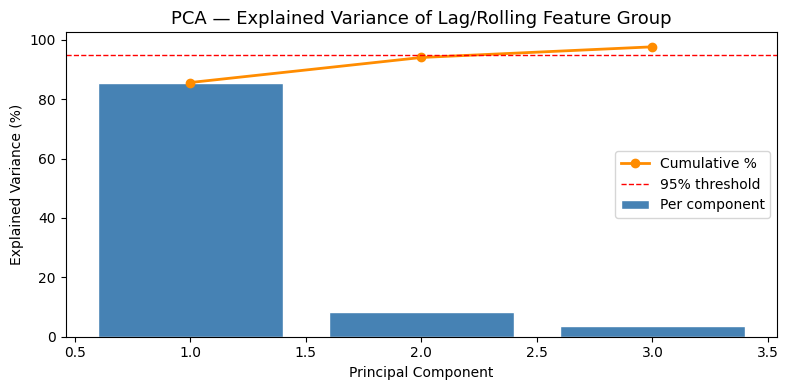

In [23]:
# Features to compress (high multicollinearity group)
pca_group = ['lag_1', 'lag_2', 'lag_24', 'lag_168', 'rolling_mean_3', 'rolling_std_3']

# Scale before PCA (PCA is variance-based — scale matters)
scaler_pca = StandardScaler()
pca_input_scaled = scaler_pca.fit_transform(final_df[pca_group].values)

# Fit PCA retaining 95% of variance
pca = PCA(n_components=0.95, random_state=42)
pca_components = pca.fit_transform(pca_input_scaled)

print(f"Original lag/rolling features  : {len(pca_group)}")
print(f"PCA components retained (95%%) : {pca.n_components_}")
print(f"\nExplained variance per component:")
for i, ev in enumerate(pca.explained_variance_ratio_):
    print(f"  PC{i+1}: {ev:.4f}  ({ev*100:.1f}%)")
print(f"  Cumulative: {pca.explained_variance_ratio_.sum()*100:.1f}%")

# Visualise explained variance
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(1, pca.n_components_+1), pca.explained_variance_ratio_*100,
       color='steelblue', edgecolor='white', label='Per component')
ax.plot(range(1, pca.n_components_+1),
        pca.explained_variance_ratio_.cumsum()*100,
        marker='o', color='darkorange', linewidth=2, label='Cumulative %')
ax.axhline(95, color='red', linestyle='--', linewidth=1, label='95% threshold')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance (%)')
ax.set_title('PCA — Explained Variance of Lag/Rolling Feature Group', fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig('pca_variance.png', dpi=120, bbox_inches='tight')
plt.show()


In [24]:
# Building & saving the PCA-transformed dataset
# Keep all non-lag columns as-is, replace lag/rolling group with PCA components

drop_cols = pca_group + ['Borough', 'hour', 'day', 'month']
other_cols = [c for c in final_df.columns if c not in drop_cols]

pca_col_names = [f'pca_lag_{i+1}' for i in range(pca.n_components_)]
pca_df = pd.DataFrame(pca_components, columns=pca_col_names, index=final_df.index)

final_df_pca = pd.concat([final_df[other_cols].reset_index(drop=True), pca_df.reset_index(drop=True)], axis=1)

# Moving trip_count to last column for clarity
cols_order = [c for c in final_df_pca.columns if c != 'trip_count'] + ['trip_count']
final_df_pca = final_df_pca[cols_order]

final_df_pca.to_parquet('taxi_demand_ml_ready_pca.parquet')

print(f"Standard dataset saved  : taxi_demand_ml_ready.parquet  — shape {final_df.shape}")
print(f"PCA dataset saved       : taxi_demand_ml_ready_pca.parquet — shape {final_df_pca.shape}")
print(f"\nPCA dataset columns: {final_df_pca.columns.tolist()}")


Standard dataset saved  : taxi_demand_ml_ready.parquet  — shape (150479, 26)
PCA dataset saved       : taxi_demand_ml_ready_pca.parquet — shape (150479, 19)

PCA dataset columns: ['PULocationID', 'time_window', 'hour_num', 'day_of_week', 'is_weekend', 'is_holiday', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'borough_Brooklyn', 'borough_EWR', 'borough_Manhattan', 'borough_Queens', 'borough_Staten Island', 'pca_lag_1', 'pca_lag_2', 'pca_lag_3', 'trip_count']


## 12. Final Data Audit

In [25]:
print('  FINAL DATA AUDIT — ML-Ready Dataset')
print(f'  Shape          : {final_df.shape}')
print(f'  Missing values : {final_df.isnull().sum().sum()}')
print(f'  Unique zones   : {final_df["PULocationID"].nunique()}')
print(f'  Date range     : {final_df["time_window"].min()} → {final_df["time_window"].max()}')
print(f'  Boroughs       : {final_df["Borough"].unique().tolist()}')
print()
print('  All columns:')
for col in final_df.columns:
    print(f'    • {col} ({final_df[col].dtype})')


  FINAL DATA AUDIT — ML-Ready Dataset
  Shape          : (150479, 26)
  Missing values : 0
  Unique zones   : 259
  Date range     : 2025-01-07 20:00:00 → 2025-02-01 00:00:00
  Boroughs       : ['EWR', 'Queens', 'Bronx', 'Manhattan', 'Staten Island', 'Brooklyn']

  All columns:
    • PULocationID (int32)
    • time_window (datetime64[ns])
    • trip_count (float64)
    • Borough (object)
    • hour (int32)
    • hour_num (int32)
    • day (int32)
    • day_of_week (int32)
    • month (int32)
    • is_weekend (int64)
    • is_holiday (int64)
    • hour_sin (float64)
    • hour_cos (float64)
    • day_sin (float64)
    • day_cos (float64)
    • lag_1 (float64)
    • lag_2 (float64)
    • lag_24 (float64)
    • lag_168 (float64)
    • rolling_mean_3 (float64)
    • rolling_std_3 (float64)
    • borough_Brooklyn (bool)
    • borough_EWR (bool)
    • borough_Manhattan (bool)
    • borough_Queens (bool)
    • borough_Staten Island (bool)
